In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    r2_score, mean_absolute_error, mean_squared_error
)

In [22]:
# VERİ YÜKLENMESİ VE TEMİZLİK 
dosya_yolu = r"C:\Users\omer\Desktop\arac_fiyat_tahmin_veri_seti_v1.csv"
veri = pd.read_csv(dosya_yolu)

alt_limit = veri['fiyat'].quantile(0.04)
ust_limit = veri['fiyat'].quantile(0.999)
veri = veri[(veri['fiyat'] >= alt_limit) & (veri['fiyat'] <= ust_limit)]

if 'marka' in veri.columns:
    veri = veri.drop(columns=['marka', 'seri', 'model'])

In [23]:
# HEDEF DEĞİŞKENLER VE ÖLÇEKLENDİRME 
veri['fiyat_kategorisi'] = pd.qcut(veri['fiyat'], q=4, labels=['Düşük', 'Orta', 'Yüksek', 'Lüks'])
X = veri.drop(columns=['fiyat', 'fiyat_kategorisi'])
y_reg = veri['fiyat']
y_cls = veri['fiyat_kategorisi']

le = LabelEncoder()
y_cls_encoded = le.fit_transform(y_cls)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=42)
_, _, y_train_cls, y_test_cls = train_test_split(X_scaled, y_cls_encoded, test_size=0.2, random_state=42)

In [24]:
# ANN REGRESYON MODELİ VE EĞİTİMİ 
ann_reg = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
ann_reg.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

print("\n🚀 ANN REGRESYON EĞİTİMİ (Fiyat Tahmini)...")
ann_reg.fit(X_train, y_train_reg, validation_split=0.2, epochs=50, batch_size=32, verbose=1)


🚀 ANN REGRESYON EĞİTİMİ (Fiyat Tahmini)...
Epoch 1/50


C:\Users\omer\anaconda3\envs\usedcar\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


968/968 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 515192389632.0000 - mae: 529733.5000 - val_loss: 137477128192.0000 - val_mae: 287290.6562
Epoch 2/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 106417266688.0000 - mae: 220868.5312 - val_loss: 76877398016.0000 - val_mae: 171262.9531
Epoch 3/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 78049918976.0000 - mae: 165730.2500 - val_loss: 65656053760.0000 - val_mae: 149018.4375
Epoch 4/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 70919249920.0000 - mae: 155193.9219 - val_loss: 60922339328.0000 - val_mae: 141065.0469
Epoch 5/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 67227484160.0000 - mae: 149320.3750 - val_loss: 57947107328.0000 - val_mae: 137964.5312
Epoch 6/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 64367218688.0000 - mae: 145446.8906 - val_loss: 55667200000.0000 - val_mae: 134123.0781
Epoch 7/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 61977460736.0000 - mae: 141718.6875 - val_loss: 53700030464.

In [25]:
# ANN SINIFLANDIRMA MODELİ VE EĞİTİMİ 
ann_cls = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])
ann_cls.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\n🎯 ANN SINIFLANDIRMA EĞİTİMİ (Segment Tahmini)...")
ann_cls.fit(X_train, y_train_cls, validation_split=0.2, epochs=30, batch_size=32, verbose=1)


🎯 ANN SINIFLANDIRMA EĞİTİMİ (Segment Tahmini)...
Epoch 1/30


C:\Users\omer\anaconda3\envs\usedcar\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7446 - loss: 0.5915 - val_accuracy: 0.8055 - val_loss: 0.4645
Epoch 2/30
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8028 - loss: 0.4599 - val_accuracy: 0.8101 - val_loss: 0.4502
Epoch 3/30
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8110 - loss: 0.4417 - val_accuracy: 0.8145 - val_loss: 0.4502
Epoch 4/30
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8180 - loss: 0.4290 - val_accuracy: 0.8233 - val_loss: 0.4272
Epoch 5/30
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8237 - loss: 0.4192 - val_accuracy: 0.8254 - val_loss: 0.4247
Epoch 6/30
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8257 - loss: 0.4104 - val_accuracy: 0.8285 - val_loss: 0.4166
Epoch 7/30
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8287 - loss: 0.4041 - val_accuracy: 0.8316 - val_loss: 0.4087
Epoch 8/30
968/968 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8338 - loss: 0.3969 - val_accuracy: 0.8309 - val_

In [32]:
# ANN TEST SONUÇLARI VE PERFORMANS ANALİZİ 
print("\n" + "="*50)
print("📊 ANN (DEEP LEARNING) TEST SONUÇLARI")
print("="*50)

# Regresyon Test Sonuçları (Sayısal Fiyat Tahmini)
y_pred_reg = ann_reg.predict(X_test).flatten()
r2_ann = r2_score(y_test_reg, y_pred_reg)
mae_ann = mean_absolute_error(y_test_reg, y_pred_reg)
rmse_ann = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print(f"Test R2 Skoru: %{r2_ann*100:.2f}")
print(f"Test MAE (Ortalama Hata): {mae_ann:,.2f} TL")
print(f"Test RMSE (Kök Hata): {rmse_ann:,.2f} TL")

# Sınıflandırma Test Sonuçları (Segment Tahmini)
y_pred_cls_probs = ann_cls.predict(X_test)
y_pred_cls = np.argmax(y_pred_cls_probs, axis=1)
accuracy_ann = accuracy_score(y_test_cls, y_pred_cls)

print(f"Sınıflandırma Doğruluğu (Accuracy): %{accuracy_ann*100:.2f}")
print("="*50)


📊 ANN (DEEP LEARNING) TEST SONUÇLARI
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Test R2 Skoru: %88.50
Test MAE (Ortalama Hata): 107,778.83 TL
Test RMSE (Kök Hata): 204,420.63 TL
303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Sınıflandırma Doğruluğu (Accuracy): %84.68


In [27]:
# Sınıflandırma Test Sonuçları
y_pred_cls_probs = ann_cls.predict(X_test)
y_pred_cls = np.argmax(y_pred_cls_probs, axis=1)

print("\n--- Sınıflandırma Raporu ---")
print(classification_report(y_test_cls, y_pred_cls, target_names=le.classes_))

303/303 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

       Düşük       0.86      0.88      0.87      2434
        Lüks       0.93      0.93      0.93      2377
        Orta       0.76      0.77      0.77      2412
      Yüksek       0.83      0.82      0.83      2455

    accuracy                           0.85      9678
   macro avg       0.85      0.85      0.85      9678
weighted avg       0.85      0.85      0.85      9678



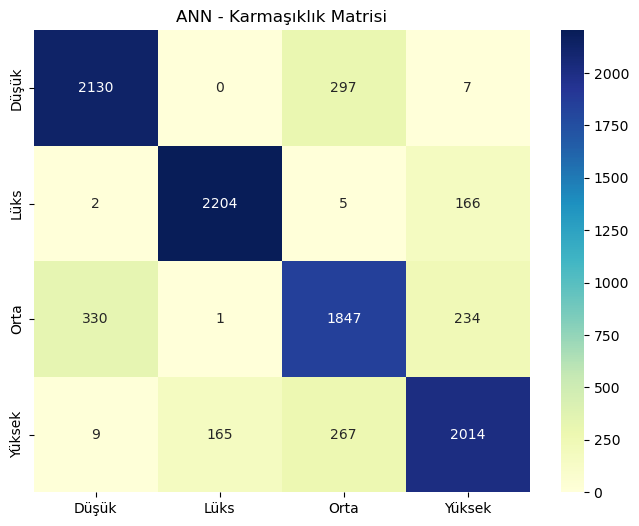

In [28]:
# GÖRSELLEŞTİRMELER 

# Karmaşıklık Matrisi
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test_cls, y_pred_cls)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('ANN - Karmaşıklık Matrisi')
plt.show()

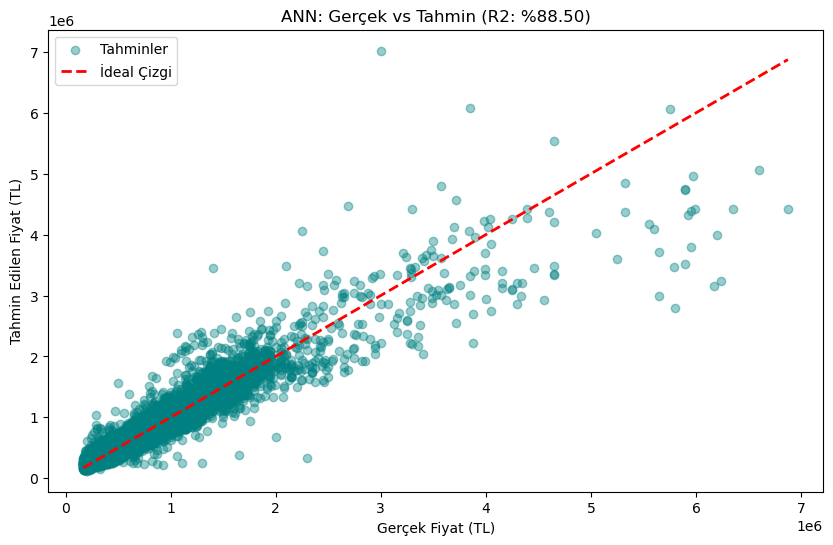

In [29]:
# Gerçek vs Tahmin Grafiği
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4, color='teal', label='Tahminler')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2, label='İdeal Çizgi')
plt.title(f'ANN: Gerçek vs Tahmin (R2: %{r2*100:.2f})')
plt.xlabel('Gerçek Fiyat (TL)')
plt.ylabel('Tahmin Edilen Fiyat (TL)')
plt.legend()
plt.show()

In [ ]:
model_meta = {
    'model': ann_reg,          
    'scaler': scaler,
    'egitim_sutunlari': X.columns.tolist(),
    'alt_limit': alt_limit,
    'ust_limit': ust_limit
}

joblib.dump(model_meta, "ann_metadata_xgboost.joblib")
print("\n✅ ANN Modeli tek joblib ile kaydedildi.")


✅ ANN Modeli tek joblib ile kaydedildi.


In [31]:
# ÖRNEK UYGULAMA 
def arac_fiyat_tahmin_ann(model_obj, meta_path, yeni_veri):
    meta = joblib.load(meta_path)
    scaler = meta['scaler']
    cols = meta['egitim_sutunlari']
    
    df = pd.DataFrame([yeni_veri])
    for c in cols:
        if c not in df.columns:
            df[c] = 0
    df = df[cols]
    df_scaled = scaler.transform(df)
    return model_obj.predict(df_scaled)[0][0]

yeni_arac = {
    "yil": 2021,
    "kilometre": 63000,
    "degisen_sayisi": 0,
    "boyali_sayisi": 0,
    "motor_hacmi_num": 1490,
    "motor_gucu_num": 125,
    "marka_num": 50,      # Toyota ID
    "seri_num": 144,      # Corolla ID
    "model_num": 940,     # 1.5 Dream ID
    "vites_tipi_Düz": 0,
    "vites_tipi_Otomatik": 1,
    "vites_tipi_Yarı Otomatik": 0,
    "yakit_tipi_Benzin": 1,
    "yakit_tipi_Dizel": 0,
    "yakit_tipi_Elektrik": 0,
    "yakit_tipi_Hibrit": 0,
    "yakit_tipi_LPG & Benzin": 0,
    "kasa_tipi_Cabrio": 0,
    "kasa_tipi_Coupe": 0,
    "kasa_tipi_Hatchback/3": 0,
    "kasa_tipi_Hatchback/5": 0,
    "kasa_tipi_MPV": 0,
    "kasa_tipi_Pick-up": 0,
    "kasa_tipi_Roadster": 0,
    "kasa_tipi_SUV": 0,
    "kasa_tipi_Sedan": 1,
    "kasa_tipi_Station wagon": 0
}

tahmin = arac_fiyat_tahmin_ann(ann_reg, "ann_metadata.joblib", yeni_arac)
print(f"\n🚀 Örnek Aracın ANN Tahmini Fiyatı: {tahmin:,.0f} TL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

🚀 Örnek Aracın ANN Tahmini Fiyatı: 1,540,444 TL
